In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
# Load the dataset (update path if needed)
df = pd.read_csv("customer_churn.csv")

# Display first 5 rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
0,C001,Female,0,Yes,No,1,Yes,Fiber optic,Month-to-month,85.00,NaN,Yes
1,C002,Male,0,No,No,34,Yes,DSL,One year,56.95,1889.50,No
2,C003,Male,0,No,No,2,Yes,Fiber optic,Month-to-month,89.10,178.20,Yes
3,C004,Male,0,Yes,No,45,No,No internet service,Two year,18.95,853.00,No
4,C005,Female,1,Yes,Yes,5,Yes,Fiber optic,Month-to-month,99.65,498.25,Yes


In [5]:
# Check data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       15 non-null     object 
 1   gender           15 non-null     object 
 2   SeniorCitizen    15 non-null     int64  
 3   Partner          15 non-null     object 
 4   Dependents       15 non-null     object 
 5   tenure           15 non-null     int64  
 6   PhoneService     15 non-null     object 
 7   InternetService  15 non-null     object 
 8   Contract         15 non-null     object 
 9   MonthlyCharges   15 non-null     float64
 10  TotalCharges     13 non-null     float64
 11  Churn            15 non-null     object 
dtypes: float64(2), int64(2), object(8)
memory usage: 1.5+ KB


In [6]:
# Summary of numerical features
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,15.000000,15.00000,15.000000,13.000000
mean,0.200000,23.00000,63.900000,1119.003846
std,0.414039,23.17326,30.411229,788.819742
min,0.000000,1.00000,18.950000,178.200000
25%,0.000000,5.50000,37.600000,498.250000
50%,0.000000,12.00000,58.600000,923.000000
75%,0.000000,39.50000,90.700000,1794.000000
max,1.000000,72.00000,99.650000,2812.800000


In [7]:
# Count of churned vs non-churned customers
df['Churn'].value_counts()


Churn
No     8
Yes    7
Name: count, dtype: int64

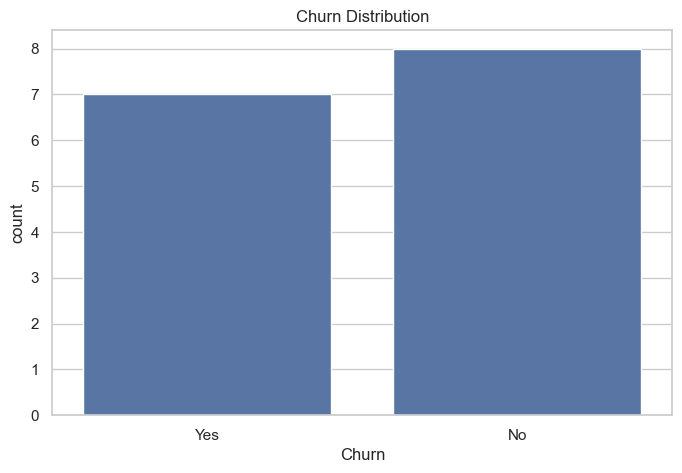

In [8]:
# Visualize churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


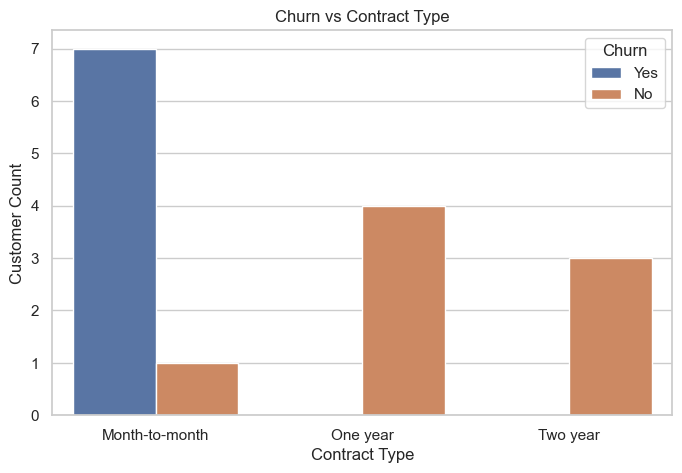

In [9]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn vs Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()


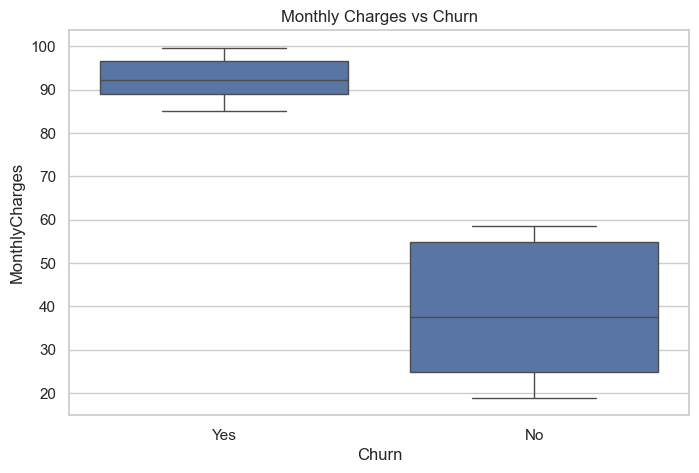

In [10]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


In [11]:
# Check missing values
df.isnull().sum()


customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
InternetService    0
Contract           0
MonthlyCharges     0
TotalCharges       2
Churn              0
dtype: int64

In [12]:
# Fill missing values in TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_13808\3977200586.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [13]:
# Standardize values
df.replace({'No internet service': 'No'}, inplace=True)


In [14]:
# Verify cleaned values
df['InternetService'].value_counts()


InternetService
Fiber optic    7
DSL            6
No             2
Name: count, dtype: int64

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       15 non-null     object 
 1   gender           15 non-null     object 
 2   SeniorCitizen    15 non-null     int64  
 3   Partner          15 non-null     object 
 4   Dependents       15 non-null     object 
 5   tenure           15 non-null     int64  
 6   PhoneService     15 non-null     object 
 7   InternetService  15 non-null     object 
 8   Contract         15 non-null     object 
 9   MonthlyCharges   15 non-null     float64
 10  TotalCharges     15 non-null     float64
 11  Churn            15 non-null     object 
dtypes: float64(2), int64(2), object(8)
memory usage: 1.5+ KB
